# SynthPop vs. BRAVA RV Kinematic Analysis

In [1]:
from pathlib import Path
import sys

from scipy.stats import binned_statistic, median_abs_deviation
from matplotlib.backends.backend_pdf import PdfPages
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from scipy.stats import norm
import matplotlib as mpl
import pandas as pd
import numpy as np
import yaml

synthdir = f"{Path.home()}/synthpop-v1"
sys.path.insert(0, synthdir)
import synthpop as sp

## Setup

In [2]:
datadir = "/fs/project/gaudi.1/crisp/synthpop/BRAVA_kinematics_testing"
catdir = f"{datadir}/catalogs/BRAVA_test"
tabdir = f"{datadir}/tables"
plotdir = f"{datadir}/plots"

workdir = f"{Path.home()}/synthpop-model-eval/brava_files"
pdfdir = f"{workdir}/pdfs"

config = f"{synthdir}/synthpop/config_files/BRAVA_test.synthpop_conf"

In [3]:
# Strings for labels
vgcstr = r"V$_{GC}$"
vbcstr = r"V$_{BC}$"
vhcstr = r"V$_{HC}$"
dispstr = r"$\sigma$"
mean_vgcstr = r"$\langle V_{\rm GC}\rangle$"
mean_vbcstr = r"$\langle V_{\rm BC}\rangle$"
mean_vhcstr = r"$\langle V_{\rm HC}\rangle$"
mean_dispstr = r"$\langle \sigma\rangle$"
pmstr = r"$\pm$"
kmpsstr = r"km s$^{-1}$"
kmpspdstr = r"km s$^{-1}$ deg$^{-1}$"

# Plot parameters
mpl.rcParams['lines.linewidth'] = 1.5
mpl.rcParams['axes.titlesize'] = 24
mpl.rcParams['axes.labelsize'] = 18
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['patch.linewidth'] = 0.5
mpl.rcParams['axes.axisbelow'] = True

In [4]:
def filter_for_surot(dataframe, l_key='l', b_key='b'):
    dataframe = dataframe[(dataframe[l_key] >= -10.0) &
                          (dataframe[l_key] <= 10.0) &
                          (dataframe[b_key] >= -10.0) &
                          (dataframe[b_key] <= 5.0)]
    dataframe.reset_index(drop=True, inplace=True)
    return dataframe

### Color Cut Function

In [5]:
def calc_color_cut(brava_df, binrange=[7.75, 10.25], binedges=[7.75, 8.25, 8.75, 9.25, 9.75, 10.25]):
    
    means, edges, _ = binned_statistic(brava_df['K'], brava_df['J']-brava_df['K'], statistic='mean', bins=binedges, range=binrange)
    sigmas, _, _ = binned_statistic(brava_df['K'], brava_df['J']-brava_df['K'], statistic='std', bins=binedges, range=binrange)
    
    mag_centers = 0.5*(edges[1:]+edges[:-1])
    
    mag_int = interp1d(mag_centers, means)
    std_int = interp1d(mag_centers, sigmas)
    return mag_int, std_int

### Plot SynthPop $<V_{bc}>$ vs. BRAVA $<V_{hc}>$

In [6]:
def plot_vbc_vhc(ax, rv_dataframe, plot_sigmas=False, **kwargs):
    if plot_sigmas:
        ax.errorbar(rv_dataframe['brava_vhc'], rv_dataframe['synth_vbc'], 
                    xerr=rv_dataframe['brava_Verr'], yerr=rv_dataframe['synth_sigma'], 
                    fmt='o')
    sc = ax.scatter(rv_dataframe['brava_vhc'], rv_dataframe['synth_vbc'], 
                    c=rv_dataframe['l'], **kwargs)
    return sc

In [7]:
def plot_vbc_vgc(ax, rv_dataframe, plot_sigmas=False, **kwargs):
    if plot_sigmas:
        ax.errorbar(rv_dataframe['brava_vgc'], rv_dataframe['synth_vbc'], 
                    xerr=rv_dataframe['brava_Verr'], yerr=rv_dataframe['synth_sigma'], 
                    fmt='o')
    sc = ax.scatter(rv_dataframe['brava_vgc'], rv_dataframe['synth_vbc'], 
                    c=rv_dataframe['l'], **kwargs)
    return sc

### Load BRAVA Table

In [8]:
# Table combining observations from Papers I and II.
# l and b are the exact coordinates given in the papers
# l_web and b_web are the rounded coordinates which they present on the BRAVA webpage
# l_round and b_round are the coordinates rounded to the nearest tenth
full_brava = pd.read_csv(f"{workdir}/BRAVA_Tables.txt", sep=r'\s+', header=0)
print(full_brava.columns.values)
print(full_brava.shape)
brava = filter_for_surot(full_brava)
print(brava.shape)

['field' 'l' 'b' 'V_hc' 'V_gc' 'err_V' 'sigma' 'err_sigma' 'N_fibers'
 'N_reliable_vel' 'l_web' 'b_web' 'l_round' 'b_round']
(78, 14)
(73, 14)


## Generate the Catalogs if Needed/Wanted

In [9]:
solang0 = 0.01
max_solang = 0.05
min_stars = 100
stop = 7

generate_catalogs = 0
if generate_catalogs == 1:
    model = sp.SynthPop(default_config=config)
    model.init_populations()
    for i, row in brava.iterrows():      
        solang = solang0
        df, dist = model.process_location(row['l'], row['b'], solang)

        num_bright = df[df.loc[:,'2MASS_Ks'] <= 10].shape[0]
        print(f"     Number of stars Ks<10 generated on attempt 1: {num_bright}")
        if num_bright < min_stars:
            solang = solang * min_stars/num_bright
            print(f"     Rerunning l={row['l']}, b={row['b']} with new solid angle {solang}")
            df, dist = model.process_location(row['l'], row['b'], solang)
            num_bright = df[df.loc[:,'2MASS_Ks'] <= 10].shape[0]
            print(f"     Number of stars Ks<10 generated on attempt 2: {num_bright}")

## Generate or Load the SynthPop Mean Velocities

In [10]:
generate_sp_gaussians_popcut = 0
if generate_sp_gaussians_popcut == 1:
    means = []
    mean_errs = []
    sigs = []
    sig_errs = []
    for i, row in brava.iterrows():
        l = row['l']
        b = row['b']

        synth = pd.read_csv(f"{catdir}/BRAVA_test_l{l:0.3f}_b{b:0.3f}.csv", sep=r'\s+', header=0)
        synth = synth[synth['pop'] == 0.0]
        N = synth.shape[0]
        
        mean_v_synth, mean_sig_synth = norm.fit(synth['vr_bc'])
        means.append(mean_v_synth)
        sigs.append(mean_sig_synth)

        mean_err = mean_sig_synth/np.sqrt(N)
        sig_err = mean_sig_synth/np.sqrt(2*N)
        mean_errs.append(mean_err)
        sig_errs.append(sig_err)
    
    synth_gauss_popcut = pd.DataFrame(list(zip(brava['l'], brava['b'], means, mean_errs, sigs, sig_errs)))
    synth_gauss_popcut.columns = ['l', 'b', 'mean_Vbc', 'mean_Vbc_err', 'sigma', 'sigma_err']
    # print(synth_gauss_popcut)

    synth_gauss_popcut.to_csv(f"{workdir}/SynthPop_Mean_Velocities.pop_cut.txt", sep=' ', header=True, index=False, na_rep='NaN')

else:
    synth_gauss_popcut = pd.read_csv(f"{workdir}/SynthPop_Mean_Velocities.pop_cut.txt", sep='\\s+', header=0)

## Fit Linear Model to RVs

In [11]:
def linear_fit(x, m, b):
    return m*x + b

In [12]:
popt_sp, pcov_sp = curve_fit(linear_fit, synth_gauss_popcut['l'], synth_gauss_popcut['mean_Vbc'])
popt_b, pcov_b = curve_fit(linear_fit, brava['l'], brava['V_hc'])

print(popt_sp, pcov_sp)
print(popt_b, pcov_b)

[  6.32459206 -20.10879835] [[ 0.01856751 -0.00247228]
 [-0.00247228  0.63846071]]
[  5.29543188 -10.3019397 ] [[ 0.08010446 -0.01066596]
 [-0.01066596  2.75446535]]


In [13]:
err_sp = np.sqrt(np.diag(pcov_sp))
err_b = np.sqrt(np.diag(pcov_b))

In [14]:
xx = np.arange(-20.0, 20.001, 0.001)
model_sp = linear_fit(xx, *popt_sp)
model_b = linear_fit(xx, *popt_b)

## Plot to Check

### Get Unique b Values for Plotting

In [15]:
def roundToHalf(array):
    return np.around(array * 2.0) / 2.0

In [16]:
brava_round_half = roundToHalf(brava['b'])
sp_round_half = roundToHalf(synth_gauss_popcut['b'])

In [17]:
b_vals = sorted(brava_round_half.unique())
b_to_i = {val: i for i, val in enumerate(b_vals)}
# print(b_to_i)

sp_index = np.array([b_to_i[val] for val in sp_round_half])
b_index = np.array([b_to_i[val] for val in brava_round_half]) 
# print(b_index)

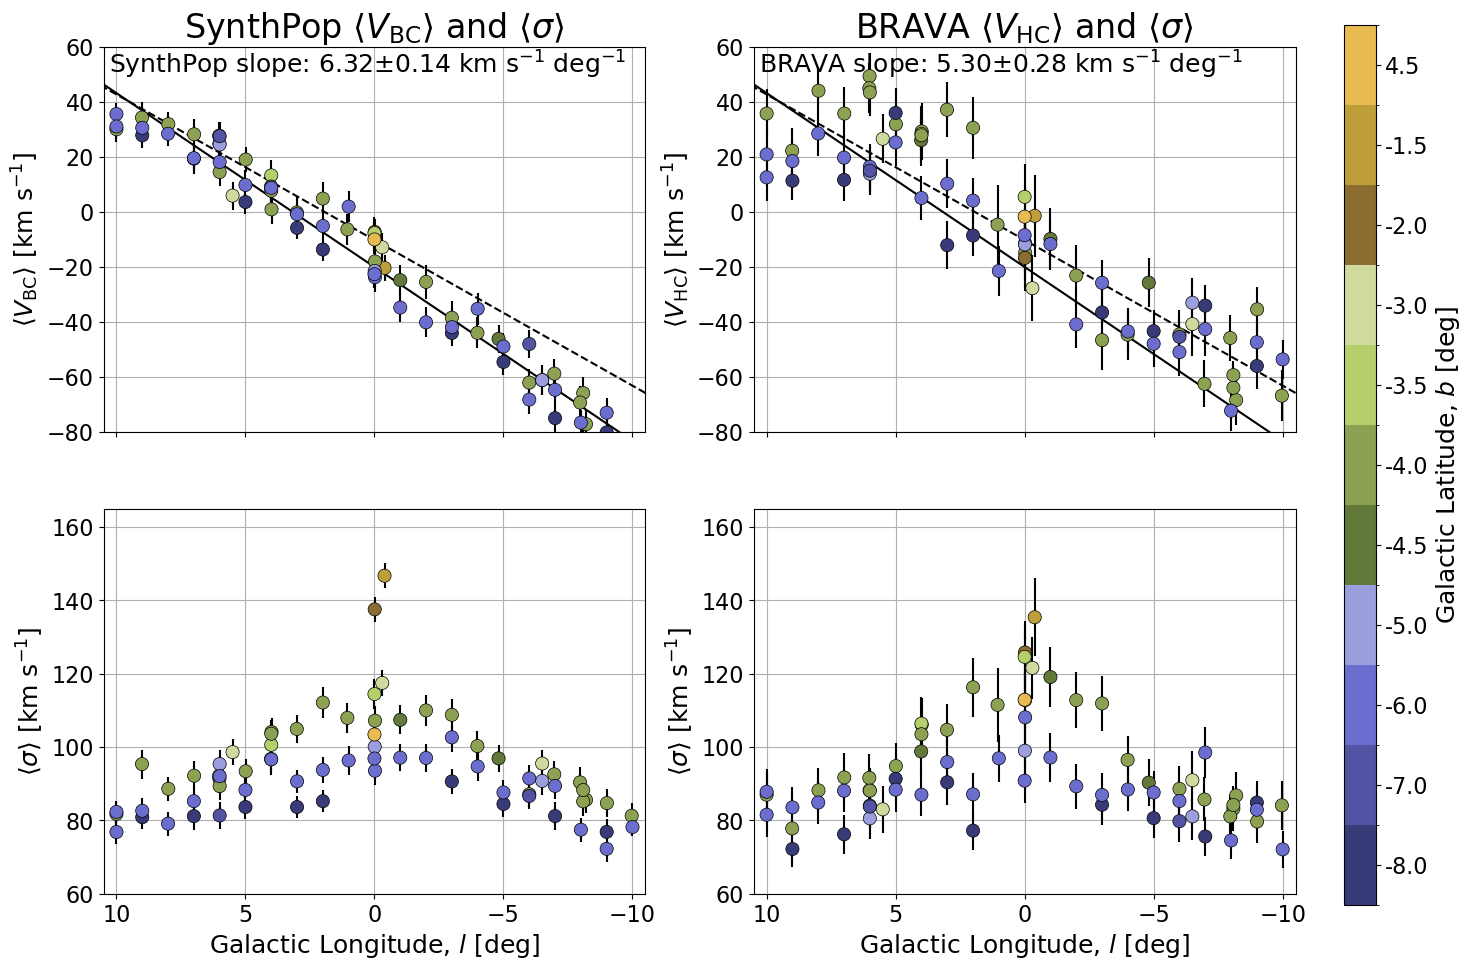

In [18]:
marker_size = 90
color_map = 'tab20b'

norm = mpl.colors.BoundaryNorm(boundaries=np.arange(-0.5, len(b_vals)+0.5, 1),
                               ncolors=len(b_vals))

fig, axs = plt.subplots(2, 2, sharex=True, figsize=(16,11))
axs[0,0].set_title(f"SynthPop {mean_vbcstr} and {mean_dispstr}")
axs[0,0].plot(xx, model_sp, 'k-')
axs[0,0].plot(xx, model_b, 'k--')
axs[0,0].errorbar(synth_gauss_popcut['l'], synth_gauss_popcut['mean_Vbc'],
                  yerr=synth_gauss_popcut['mean_Vbc_err'], fmt='k.')
sc00 = axs[0,0].scatter(synth_gauss_popcut['l'], synth_gauss_popcut['mean_Vbc'], c=sp_index, 
                        cmap=color_map, norm=norm, s=marker_size, ec='k', zorder=100)
axs[0,0].text(0.01, 0.93, f"SynthPop slope: {popt_sp[0]:0.2f}{pmstr}{err_sp[0]:0.2f} {kmpspdstr}", 
              transform=axs[0,0].transAxes, fontsize=18)
axs[0,0].set_xlim(-10.5, 10.5)
axs[0,0].invert_xaxis()
axs[0,0].set_ylabel(f"{mean_vbcstr} [{kmpsstr}]")
axs[0,0].set_ylim(-80, 60)
axs[0,0].grid()


axs[0,1].set_title(f"BRAVA {mean_vhcstr} and {mean_dispstr}")
axs[0,1].plot(xx, model_sp, 'k-')
axs[0,1].plot(xx, model_b, 'k--')
axs[0,1].errorbar(brava['l'], brava['V_hc'],
                  yerr=brava['err_V'], fmt='k.')
sc01 = axs[0,1].scatter(brava['l'], brava['V_hc'], c=b_index, 
                        cmap=color_map, norm=norm, s=marker_size, ec='k', zorder=100)
axs[0,1].text(0.01, 0.93, f"BRAVA slope: {popt_b[0]:0.2f}{pmstr}{err_b[0]:0.2f} {kmpspdstr}", 
              transform=axs[0,1].transAxes, fontsize=18)
axs[0,1].set_ylabel(f"{mean_vhcstr} [{kmpsstr}]")
axs[0,1].set_ylim(-80, 60)
axs[0,1].grid()


axs[1,0].errorbar(synth_gauss_popcut['l'], synth_gauss_popcut['sigma'],
                  yerr=synth_gauss_popcut['sigma_err'], fmt='k.')
sc10 = axs[1,0].scatter(synth_gauss_popcut['l'], synth_gauss_popcut['sigma'], c=sp_index, 
                        cmap=color_map, norm=norm, s=marker_size, ec='k', zorder=100)
axs[1,0].set_xlabel(r"Galactic Longitude, $l$ [deg]")
axs[1,0].set_ylabel(f"{mean_dispstr} [{kmpsstr}]")
axs[1,0].set_ylim(60, 165)
axs[1,0].grid()


axs[1,1].errorbar(brava['l'], brava['sigma'],
                  yerr=brava['err_sigma'], fmt='k.')
sc11 = axs[1,1].scatter(brava['l'], brava['sigma'], c=b_index, 
                        cmap=color_map, norm=norm, s=marker_size, ec='k', zorder=100)
axs[1,1].set_xlabel(r"Galactic Longitude, $l$ [deg]")
axs[1,1].set_ylabel(f"{mean_dispstr} [{kmpsstr}]")
axs[1,1].set_ylim(60, 165)
axs[1,1].grid()

fig.subplots_adjust(right=0.87)
cbar_ax = fig.add_axes([0.9, 0.1, 0.02, 0.8])
cbar = fig.colorbar(sc11, cax=cbar_ax, label=r"Galactic Latitude, $b$ [deg]")
cbar.set_ticks(range(len(b_vals)))
cbar.set_ticklabels(b_vals)